---
title: "Boom Markets - Dotcom & Mortgage Credit"
---

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime as dt


AD/CS561 Assignment #2 Dataset Guide

Part A – Dot-Com Boom
- dotcom_market_timeseries.csv : macro and market indicators
- dotcom_firm_fundamentals_1999.csv : cross-sectional firm snapshot
- dotcom_ipo_vc_timeseries.csv : IPO counts and VC inflows
- dotcom_contemporary_commentary.csv : qualitative context quotes

Part B – Mortgage Credit Boom
- mbs_deals_2006.csv : deal-level borrower/structure metrics
- mbs_tranche_structure_2006.csv : attachment/detachment points
- mbs_macro_stress_scenarios.csv : optional macro stress context

All numbers are stylized but plausible. Use them to support arguments,
not to search for a single “correct” answer.


# Part A - The Dot-Com Boom

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
file_path01 = '/content/drive/MyDrive/AD561/Assignments/Assignment 2/dotcom_contemporary_commentary.csv'
dotcom_contemporary_commentary= pd.read_csv(file_path01)

file_path02 = '/content/drive/MyDrive/AD561/Assignments/Assignment 2/dotcom_firm_fundamentals_1999.csv'
dotcom_firm_fundamentals_1999= pd.read_csv(file_path02)

file_path03 = '/content/drive/MyDrive/AD561/Assignments/Assignment 2/dotcom_ipo_vc_timeseries.csv'
dotcom_ipo_vc_timeseries = pd.read_csv(file_path03)

file_path04= '/content/drive/MyDrive/AD561/Assignments/Assignment 2/dotcom_market_timeseries.csv'
dotcom_market_timeseries = pd.read_csv(file_path04)

## Commentary

In [28]:
pd.set_option('display.max_colwidth', None)
dotcom_contemporary_commentary

,date,excerpt
0,1998-09-01,Internet adoption is accelerating; profitability can come later once scale is achieved.
1,1999-02-01,Online brokerages are making markets feel accessible to everyone.
2,1999-08-01,Network effects justify premium multiples for category leaders.
3,1999-12-01,Traditional metrics may not capture intangible value.
4,2000-03-01,A shift in rates could reprice long-duration growth quickly.
5,2000-10-01,Liquidity is thinner than it appears when sentiment turns.
6,2001-03-01,Survivors are cutting burn and focusing on unit economics.


Insights up till late 1999:
- Internet is begining to be adopted with rapid growth. Little concern for profitability during this time.

- Online brokerages allow markets to be more accessible. Greater uptake in investing by the "common man" who did not have the education or access previously.

- Network effects (product/service becomes more valuable as the number of users/resources grows) justify the premium multiples assessing stock values.


- Traditional ways of assessing value may not be able to capture the value of the dotcom era due to intangible value.


## Firm Fundamentals

In [29]:
dotcom_firm_fundamentals_1999.head()

,firm_id,sector,revenue_1999_mil_usd,revenue_growth_1999_pct,net_margin_1999_pct,price_to_sales_1999,price_to_earnings_1999,market_cap_1999_mil_usd,cash_on_hand_mil_usd,annual_cash_burn_mil_usd
0,DC001,Semiconductors,114.2,82.1,30.5,6.39,12.7,729.5,66.5,0.0
1,DC002,Internet/Software,36.9,92.9,-6.2,39.10,NaN,1441.9,362.0,2.2
2,DC003,Semiconductors,326.6,93.1,-11.2,12.78,NaN,4171.8,160.9,24.1
3,DC004,Telecom,164.7,43.4,35.0,11.63,81.8,1915.7,33.7,0.0
4,DC005,Networking,63.6,96.9,-39.9,9.09,NaN,577.8,54.7,24.1


## IPO VC Timeseries

In [30]:
dotcom_ipo_vc_timeseries.head()

,month,tech_ipo_count,vc_inflows_bil_usd
0,1998-01-01,17,4.03
1,1998-02-01,18,4.89
2,1998-03-01,25,3.44
3,1998-04-01,15,5.40
4,1998-05-01,19,4.71


In [31]:
s = dotcom_ipo_vc_timeseries["tech_ipo_count"]
print(f"Tech IPO Count % Change from Jan 1998 to Dec 1999 is {(s.iloc[23]-s.iloc[0])/s.iloc[0]*100:.2f}%")

s = dotcom_ipo_vc_timeseries["vc_inflows_bil_usd"]
print(f"VC Inflows % Change from Jan 1998 to Dec 1999 is {(s.iloc[23]-s.iloc[0])/s.iloc[0]*100:.2f}%")

Tech IPO Count % Change from Jan 1998 to Dec 1999 is 264.71%
VC Inflows % Change from Jan 1998 to Dec 1999 is 342.18%


## Market Timeseries

In [32]:
dotcom_market_timeseries.head()

,month,nasdaq_index_level,fed_funds_rate_pct,tech_ipo_count,vc_inflows_bil_usd,median_price_to_sales,share_unprofitable_recent_ipos,retail_participation_proxy,margin_debt_index
0,1998-01-01,1849,5.50,13,3.49,7.57,0.510,0.222,60.2
1,1998-02-01,1891,5.70,15,4.93,7.16,0.424,0.209,64.2
2,1998-03-01,2081,5.66,21,4.16,6.36,0.467,0.222,56.3
3,1998-04-01,1949,5.95,15,5.24,7.76,0.450,0.225,66.9
4,1998-05-01,2105,5.96,19,5.10,6.13,0.535,0.258,70.1


In [33]:
dotcom_market_timeseries["month"] = pd.to_datetime(dotcom_market_timeseries["month"])

In [34]:
s = dotcom_market_timeseries["nasdaq_index_level"]
print(f"NASDAQ % Change from Jan 1998 to Dec 1999 is {(s[23]-s[0])/s[0]*100:.2f}%")

s = dotcom_market_timeseries["median_price_to_sales"]
print(f"Median Price-to-Sales % Change from Jan 1998 to Dec 1999 is {(s[23]-s[0])/s[0]*100:.2f}%")

s = dotcom_market_timeseries["margin_debt_index"]
print(f"Margin Debt % Change from Jan 1998 to Dec 1999 is {(s[23]-s[0])/s[0]*100:.2f}%")

s = dotcom_market_timeseries["retail_participation_proxy"]
print(f"Retail Participation % Change from Jan 1998 to Dec 1999 is {(s[23]-s[0])/s[0]*100:.2f}%")

NASDAQ % Change from Jan 1998 to Dec 1999 is 146.67%
Median Price-to-Sales % Change from Jan 1998 to Dec 1999 is 176.09%
Margin Debt % Change from Jan 1998 to Dec 1999 is 166.94%
Retail Participation % Change from Jan 1998 to Dec 1999 is 116.22%


# A1 - Recommendation

Recommendation: Underweight

Based on the timeframe of late 1999, I recommend underweight exposure to the dotcom sector for a long-term institutional investor. While the data and market sentiment show strong top-line momentum, there is a widening gap between prices and sustainable fundamentals. In the timeseries data, we can see the NASDAQ rising from 1,849 in Jan 1998 to 4,561 in Dec 1999 (+147%), while the median price-to-sales mutliple rapidly expands from 7.57 to 20.90 (+176%), showing a 2.8x valuation re-rating. Leverage and participation also increase, with the margin debt increasing from 60.2 to 160.7 (+167%), and the retail participation rising from 0.222 to 0.480 (+116.22%). These trends are consistent with late-cycle speculative dynamics. Issuance and funding also accelerated in this time period, with tech IPO counts rising from 17 in Jan 1998 to 62 in Dec 1999 (+264.71%). VC inflows matched similar growth going from \$4.03B to \$17.82B, (+342.18%). However, cause for some concern comes from the firm fundamentals with many companies show negative net margins and no earnings (P/E not meaningful), depsite having very high valuations. Finally, contemporary comemtary suggests narrative-driven pricing models, claiming that traditional metrics may not be full capturing intangible value. These indicators suggest that there is a market environment where valuation explansion, capital inflows, leverage and speculative narratives are outrunning underlying fundamentals, leading to inflation valuations.



# A2 - Evidence

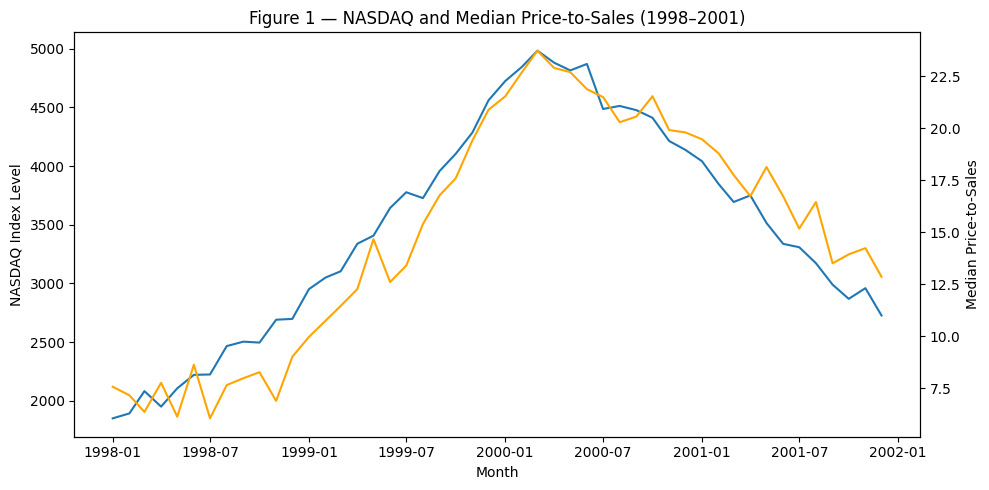

In [35]:
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(dotcom_market_timeseries["month"],
         dotcom_market_timeseries["nasdaq_index_level"],
         label="NASDAQ")

ax1.set_xlabel("Month")
ax1.set_ylabel("NASDAQ Index Level")

ax2 = ax1.twinx()

ax2.plot(dotcom_market_timeseries["month"],
         dotcom_market_timeseries["median_price_to_sales"],
         label="Median Price-to-Sales",
         color="orange")

ax2.set_ylabel("Median Price-to-Sales")

plt.title("Figure 1 — NASDAQ and Median Price-to-Sales (1998–2001)")

plt.tight_layout()
plt.show()

Figure 1 shows the NASDAQ level alongside the medain price-to-sales ratio from 1998 to 2001. Both data points show a sharp increase throughout 1998 & 1999. The NASDAQ increases roughly from 1,849 to 4,561, while the median price-to-sales ratio rises from 7.57 to 20.90. The parallel increase suggests that the appreciation in market value is driven by multiple expansion rather than pure fundamental earnings growth. A key takeaway here is that the valuations rose substantially throughout this period, indicating increasingly optimistic market expectations. Ultimately this supports the underweight reccomendation, with rapidly expanding valuation multiples can signal speculative conditions and elevated downside risk.

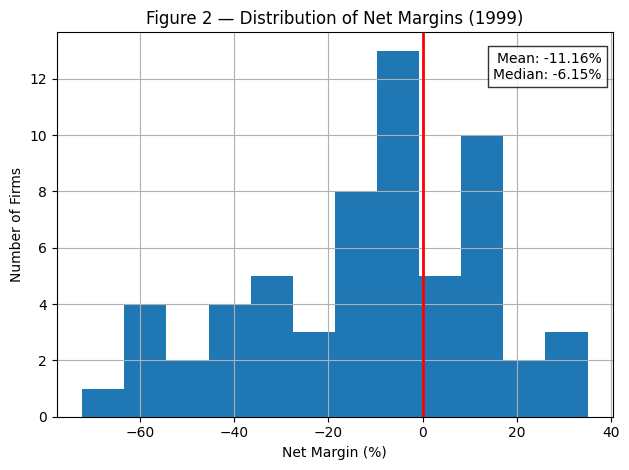

In [36]:
data = dotcom_firm_fundamentals_1999["net_margin_1999_pct"]

mean_val = data.mean()
median_val = data.median()

plt.figure()

data.hist(bins=12)

plt.xlabel("Net Margin (%)")
plt.ylabel("Number of Firms")
plt.title("Figure 2 — Distribution of Net Margins (1999)")

plt.axvline(x=0, color="red", linestyle="-", linewidth=2)

plt.text(
    0.98, 0.95,
    f"Mean: {mean_val:.2f}%\nMedian: {median_val:.2f}%",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)

plt.tight_layout()
plt.show()

Figure 2 shows the distribution of the firm net profits for technology companies in 199. The histogram shows that there is a large share of firms that reported negative probability, with many companies operating at substanital losses, despite there strong revenue growth. The mean net margin is -11.16% and the median is -6.15%, meaning the typical firm is operating as a loss, while only a small portion of the firms display positive net margins. A large concentration fall between 0% and -20%, with the largest skewing to the left with loses exceeding -60%. The key takeaway here is that profitability across the sector was highly uneven and often weak, suggesting that many firms have not yet achieved sustainable business models depsite high growth. This pattern supports the underweight recommendation, as high market valuations combined with widespread profitability indicate a potential disconnect between market prices and underlying fundamentals.

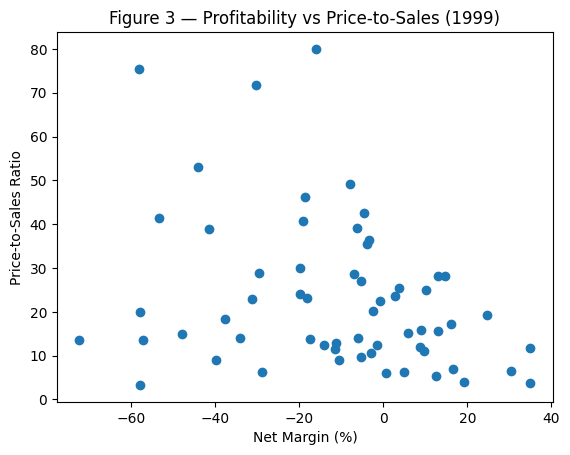

np.float64(-0.29920593281465085)

In [37]:
plt.figure()

x = dotcom_firm_fundamentals_1999["net_margin_1999_pct"]
y = dotcom_firm_fundamentals_1999["price_to_sales_1999"]

plt.scatter(x, y)

plt.xlabel("Net Margin (%)")
plt.ylabel("Price-to-Sales Ratio")
plt.title("Figure 3 — Profitability vs Price-to-Sales (1999)")

plt.show()

corr = x.corr(y)
corr

Figure 3 looks at the relationship between the firms profitability and its valuation. The scatterplot compares net profit margins with price-to-sales ratios across technology firms in 1999. While it may be expected that profitable firms will command a higher valuation, the relationship here is actually very weak. The correlation between these two variables is -0.3, indicating that there is only a weak negative relation between the profitability and valuation. Several firms here have large negative margins, yet still trade at incredibly high multiples, with some companies valued significantly above their sales. The main takeaway here is that the valuations appear only loosely tied to tangible profits, suggesting that investor pricing is very much influenced by growth narratives and optimism for the industry. Thi supports the underweight reccomendation with some hesitation on how price-to-sales and the net margin reflect credible value.

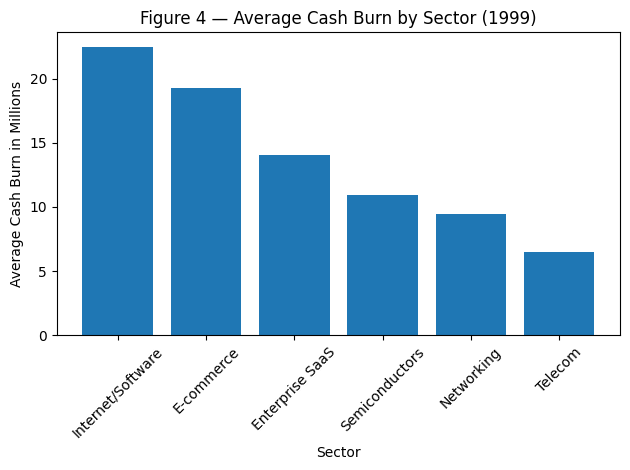

In [38]:
sector_ps = (
    dotcom_firm_fundamentals_1999
    .groupby("sector")["annual_cash_burn_mil_usd"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()

plt.bar(sector_ps.index, sector_ps.values)

plt.xticks(rotation=45)
plt.xlabel("Sector")
plt.ylabel("Average Cash Burn in Millions")
plt.title("Figure 4 — Average Cash Burn by Sector (1999)")

plt.tight_layout()
plt.show()

Figure 4 shows the averge cash burn across the technology sectiors. Internet/Software firms show the highest average cash burn at approximately \$22.5 million per year, with E-commerce close behind at around \$19 million. In contrast, the more established sectors such as Telecommunications and Networking are burning substantially less cash, ranging between \$6 - \$10 million. The most important feature here is that the internet focused companies are showing clear rates of cash spend, while they are operating with ongoing losses. While this is likely tied to their aggressive growth mindset, it shows that perhaps there high cash spend is tied to overconfidence from external funding sources. Strong dependence on capital markets increases their long-term vulnerability if investor sentiment or market conditions change, therefore supporting the underweigh reccomendation.

In [39]:
table1 = (
    dotcom_firm_fundamentals_1999
    .groupby("sector")
    .agg(
        Firms=("firm_id", "count"),
        Avg_Revenue=("revenue_1999_mil_usd", "mean"),
        Avg_Revenue_Growth_pct=("revenue_growth_1999_pct", "mean"),
        Avg_Net_Margin_pct=("net_margin_1999_pct", "mean"),
        Avg_Price_to_Sales=("price_to_sales_1999", "mean"),
    )
    .sort_values("Avg_Price_to_Sales", ascending=False)
    .head(10)
    .round(2)
)

print("Table 1 — Sector-level fundamentals and valuation (1999)")
display(table1)

Table 1 — Sector-level fundamentals and valuation (1999)


,Firms,Avg_Revenue,Avg_Revenue_Growth_pct,Avg_Net_Margin_pct,Avg_Price_to_Sales
sector,,,,,
Internet/Software,11,82.91,115.83,-33.19,36.07
E-commerce,11,138.68,91.57,-17.79,31.60
Networking,7,160.67,91.01,-3.69,26.60
Enterprise SaaS,6,116.02,99.03,-3.38,18.37
Telecom,9,118.73,64.02,6.39,13.87
Semiconductors,16,84.49,81.25,-7.50,13.65


The table summarizes sector-level fundamentals and valuation metrics for technology firms in 1999, including the number of firms, average revenue, average revenue growth, average net margins, and average price-to-sales ratios. The data shows several key factors, particularly in the Internet/Software and E-commerce sectors which demonstrate extremely high revenue growth (115% and 91% respectively) but also strongly negative average profit margins (-33% and -17% respectively). Despite weak profitability, these sectors command the highest valuation multiples, with price-to-sales ratio exceeding 30. In contrast, more established sectors such as telecommunications and semiconductors show lower valuation multiples and somewhat stronger profitability. The key takeaway is that the market valuations appear disconnected from profitability, suggesting that investor expectations for future growth may be overly optimistic. High growth rates are not accurately reflecting in their key valuation multiples. Again, this supports the underweight recommendation for long-term investors.

# A3 - Assumptions

## Assumption 1: Revenue Growth Translates into Sustainable Profitability

A key assumption underlying the underweight recommendation is that the firms' current high revenue growth will not translate into sustainable profitability. The firm-level data shows extremely strong average revenue growth across several sectors - including Internet/Software firms averaging 115.8% revenue growth and E-commerce avergaging 91.6% growth. However, both of these sectors also show substanital negative net margins at -33.2%$ for Internet/Software and -17.8% for E-commerce. My recommendation assumes that achieving profitability will take longer and require more capital than the current market valuations imply. If firms were in fact able to convert growth into profits much more rapidly can expected, current valuations might be justified and the sector could continue to outperform my expectations.


## Assumption 2: Valuation Multiples will Eventually Revert Towards Levels Supported By Fundamentals

The recommendation also assumes that the extreme valuation multiples observed in the sector will eventually normalize. Median price-to-sales ratios rose from roughly 7.6 in early 1998 to 20.9 by late 1999, indicating a rapid rise in ratings for technology stocks. At the firm level, certain sectors experienced even higher averages such as 36.1 for Internet/Software and 31.6 for E-commerce. The assumption is that these multiples are unsustainably high relative to their underlying profitability and will eventually decline as investor expectations become more realistic. If instead, the market continues to reward growth companies with persistently high valuations, the sector could maintain strong performance despite weak current earnings

# A4 - Fragility Scenario

A severe decline in the dot-com sector could occur through a number of connected events that expose the gaps between market valuations and underlying firm fundamentals.

1. The first trigger may be a shift in monetary conditions, such as an increase in interest rates or tighter financial conditions. The contemporary commentary dataset specifically calls out this situation - "a shift in rates could reprice long-duration growth quickly". Higher interest rates would reduce the present value of of future earnings and disproportionately affect technology companies whose valuations rely heavily on expected future growth.

2. With financial conditions tightening, investor sentiment may begin to shift. The data shows strong signs of speculative activity late in 1999, including rapid growth in retail participation (0.222 - 0.480), and a sharp increase in margin debt index (60.2 - 160.7). If sentiment turns, leveraged investors may be forced to reduce positions quickly, accelerating downward price movements.

3. A decline in the share prices would then disrupt the financing environment for technology companies. The sector relies heavily on external capital, as shown by the rapid expansion in venture capital inflows from \$4.03B to \$17.82B and increasing the number of technology IPOs. Many firms will also operate with negative profit margins and ongoing cash burn, meaning they depend on continued access to funding to sustain operations.

4. If the equity markets weaken and new capital becomes more difficult to raise, weaker firms may begin cutting spending or failing outright. The dynamic here is mentioned in the commentary stating that surving companies are "cutting burn and focusing on unit economics". As firms reduce their spending, revenue growth could slow significantly, undermining the growth expectations that justified their high valuations initally.

5. Finally, as the earnings dissapointments accumulate and investor confidences begins to dwindle, valuation multiples may compress rapidly. Since the sector experience dramatic multiple expansion during the boom - median price-to-sales ratios rising to roughly 20.9 by late 1999, even moderate downward revisions in expectations could lead to large price downward price movements.

Following this chain of events, tightening financial conditions, shifting investor sentiment, reduced capital availability and collapsing valuation multiples, a sharp and widespread decline in technology and equity prices may occur.

# Part B - The Mortgage Credit Boom

In [40]:
file_path05 = '/content/drive/MyDrive/AD561/Assignments/Assignment 2/mbs_deals_2006.csv'
mbs_deals_2006= pd.read_csv(file_path05)

file_path06 = '/content/drive/MyDrive/AD561/Assignments/Assignment 2/mbs_macro_stress_scenarios.csv'
mbs_macro_stress_scenarios= pd.read_csv(file_path06)

file_path07 = '/content/drive/MyDrive/AD561/Assignments/Assignment 2/mbs_tranche_structure_2006.csv'
mbs_tranche_structure_2006 = pd.read_csv(file_path07)


In [41]:
mbs_deals_2006

,deal_id,deal_name,avg_fico,avg_ltv,pct_owner_occupied,geo_sunbelt_share_pct,equity_pct,mezz_pct,senior_attach_pct,senior_yield_pct
0,A,Sunbelt Prime Trust 2006-A,735,78,86,72,3,4,7,4.75
1,B,Metro Alt-A Income Trust 2006-B,705,85,72,25,6,5,11,5.15
2,C,Frontier Opportunity Mortgage Trust 2006-C,655,92,60,40,10,6,16,6.10


Evaluating Borrower Risk: FICO, LTV, Owner Occupancy, Geography

How Much Protection Exists: Equity %, Mezz %, Attachment %

Market Belief: Yield

In [42]:
mbs_macro_stress_scenarios

,scenario,house_price_change_pct,unemployment_rate_pct,refi_activity_index,correlation_rho
0,Base,5,4.8,120,0.12
1,Moderate Stress,-10,6.2,85,0.20
2,Severe Stress,-25,8.0,55,0.32


In [43]:
mbs_tranche_structure_2006

,deal_id,tranche,attach,detach
0,A,Equity,0.00,0.03
1,A,Mezz,0.03,0.07
2,A,Senior,0.07,1.00
3,B,Equity,0.00,0.06
4,B,Mezz,0.06,0.11
5,B,Senior,0.11,1.00
6,C,Equity,0.00,0.10
7,C,Mezz,0.10,0.16
8,C,Senior,0.16,1.00


# B1 - Deal Ratings

## Deal A - Sunbelt Prime Trust 2006-A

Rating: AAA-like Safe

Supporting Evidence:
- Average Borrower Quality is High (average FICO score of 735), with moderate leverage (average LTV of 78%), and high stability (86% owner-occupied houses).
- Senior Tranche has substantial protection, attaching at 7% (3% equity and 4% mezz), paying a reasonably low 4.75% yield.

Risk Factor:
- Geographic concentration is high (72%) sunbelt share, increasing the correlated risk if the region weakens.

Overall Verdict:
- Strong collateral quality plus a 7% loss buffer supports a top-tier rating, with location concentration as the main caveat.


## Deal B - Metro Alt-A Income Trust 2006-B

Rating: Investment-grade but risky

Supporting Evidence:
- Collateral is weaker than Deal A, with a weaker average FICO of 705 and higher leverage with 85% LTV, and only 72% owner occupied.
- Structure is stronger than Deal A; senior attaches itself at 11% (6% equity, 5% mezz), and the senior yield at 5.15% suggests moderate risk pricing.

Risk Factor:
- With an 85% LTV, a moderate housing downturn can push many loans towards negative equity faster than Deal A.

Overall Verdict:
- Enhanced protection (11%) supportes investment-grade status, but higher leverage keeps loss risk meaningfully elevated.



## Deal C - Frontier Opportunity Mortgage Trust 2006-C

Rating: Frontier Opportunity Mortgage Trust 2006-C

Supporting Evidence:
- Borrower risk is high with an average FICO score of 655, very high leverage with 92% LTV, and lower stability of only 60% owner occupancy.
- Senior protection is very strong (attaches at 16%, 10% equity and 6%), but the senior yield is the higher at 6.10%, consistent with elevated risk.

Risk Factor:
- Highly exposed to housing-price and refi conditions, under severe stress (-25% prices, refi index 55), defaults and severities can rise sharply.

Overall Verdict:
- Despite 16% credit enhancement, the collateral profile with weak enough that senior loss risk remains non-trivial.

# B2 - Relative Risk Ranking

1. Deal A
Deal A is the safest because it combines the strongest borrower quality (average FICO 735, LTV of 78%, Owner-Occupany of 86%), which reduces the deafault likelihood under reasonable conditions. Its structural protection is thinner than the others (senior attaches at 7%), but the collateral strength and low senior yield (4.75%) align with the lower expected loss risk. The main weakness is the 72% sunbelt concentration.

2. Deal B
Deal B borrowers are weaker and more levered (average FICO 705, LTV of 85%), but the structure provides a larger buffer (senior attaches at 11%) and the housing diversification is better (25% sunbelt). There is a clear trade-off between higher expected losses than Deal A but more inherent protection.

3. Deal C
Deal C is the riskiest because the collateral is substantially weaker (FICO 655, LTV of 92%, 60% Owner-Occupancy). Despite having the largest enhancement (senior attaches at 16%), the deal is more vulnerable to house-price declines, reduced refinancing, consistent with a higher yield (6.10%).

# B3 - Force Investment Choice

If a conservative institution must invest in only one deal, the best choice is Deal A (Sunbelt Prime Trust 2006-A), because of its strong underlying borrower fundamentals and the lowest leverage profile. These two factors reduce the probability that losses ever approach the senior attachment point. Deal A's collateral quality is significantly better than the alternative deals: with an average FICO of 735 vs. 705 & 655 respectively. It also has lower leverage with an average LTV of 78% vs. 85% & 92% respectively. Lower leverage gives borroers more equity and reduces the strategic default incentives if house prices fall. The pool is also more attratice as the owner-occupancy is higher than the other deals at 86% vs 72% and 60%. This means that owners are less likely to default versus if they are not occupants and are purely investors. These features of borrower fundamentals reduce the expected defaults under reasonable economic conditions. Structurally, Deal A's senior tranche attaches at 7% (3% equity, 4% mezz). While this is thinner than Deal B (11%) and Deal C (16%), a conservative institution should prioriize the likelihood that losses reach those levels. With strong borrowers and low LTV's, Deal A is less likely to generate deep losses in the first place - consistent with lower yield (4.75%). The main concern with Deal A is the concentrated exposure to the sunbelt region (72%), increasing the correlated-loss risk if that geography experiences a sharp downturn. Despite this - when compared with Deal B and C, where fundamental leverage and borrower quality is lower making outcomes more sensitive to house-price and refi conditions - Deal A provides the best choice of action for a conservative investor.


# B4 - Fragility Triggers

Deal A: Geographic Concentration
- Deal A remains safe only if housing conditions across the Sunbelt region remain stable. With the pool highly concentrated (72%) in the Sunbelt region, there is inherent correlation risk. If regional house prices deceline or employment weakens simultaneously, defaults could rise across many loans all at once, rather than independently. With a lower senior tranche (7%), concentrated losses could accumulate quickly and erode any protection to senior investors despite their strong borrower fundamentals.


Deal B: Leverage Sensitivity
- Deal B depends on the housing losses remaining moderate. Borrowers in this deal are more leveraged (85% LTV) and have slightly weaker credit risks (705 FICO). If house prices decline or unemployment rises, borrowers may enter negative equity sooner, increasing default incentives and loss severity. While the senior tranche benefits from stronger protection, the safety is dependent on the losses staying below that threshold. A sustained correction in the housing market could quickly diminish the layers, allowing losses to move towards the senior bonds.


Deal C: Housing-Price Dependence
- Deal C's safety relies on stable or rising house prices. The collateral is weak with low FICO score (655 avg.), highly leveraged individuals (92%), with only 60% owner-occupied properties suggesting elevated strategic default risks.Borrowers effectively depend on refinancing or price appreciation to maintain their equity. Under severe stress conditions, widespread negative equity could cause default escalation. Despite susbtainly credit enhancement, losses could exceed structural protection, exposing senior investors to principtal impairment.

# Final Section

### Which environment showed clearer warning signs at the time?

I believe the dotcom environment displayed clearer warning signs at the time, based on the data provided. Technology firms clearly exhibited extremely rapid revenue growth but widespread negative profitability, particualrly in Internet/Software and E-commerce sectors, where the average net margins were -33% and -18% respectively, despite very high valuation multiples. At the same time, market indicators showed signs of speculation as the NASDAQ rose from 1,849 to 4,561, median price-to-sales ratios expanded from 7.6 to 20.9, as well as margin debt and retail participation increasing sharply. In contrast - the mortgage credit boom appeared a lot more stable because of the structured securities which included credit enhancement layers. This masked many of the underlying risks to borrower leverage and housing dependence.

### Which collapse seemed more predictable based on the information available at the time?

The dotcom collapse seems to be more predictable based on the data available. Valuations had rise dramatically despite the weak profitability across many of the firms, which may have suggested that the prices were increasingly driven by the expectations of future growth, rather than realized earnings. Largely it was overconfidence and high capital funding that accelerated artifical growth valuations that were not realizing profits. Based on the prior analysis, it seems more clear that this collapse was more predictable, but with the complete data we can put the rapid growth into greater context than in live time. In contrast - the mortgage credit boom involved more complex securitization structures that obscured underlying risks. Mortgage-backed securities appeared to be safe due to structural protections, including the 7%, 11%, and 16% senior attachment points observed across the deals that were evaluated. Rating agencies evaluated their losses under moderate economic conditions, this meant that they could still recieve strong ratings despite highly leveraged borrowers with loan-to-value ratios as high as 92%. As a result, the systemic fragility of the mortgage marked was far less transparent to investors at the time due to its complex nature.

### Share lessons about bubbles, risk and financial narratives

Both of these cases illustrate how financial narratives can drive asset prices beyond levels that can be explained by fundamental analysis. The dotcom boom highlighted how investors believed in rapid technological innovation and network effects to generate large profits in an exciting new industry. These beliefs led to extremely high valuation multiples, depsite negative earnings. While it can be exciting to jump on new trendy investment opportunities, there is a lesson on throrough analysis and evaluating metrics beyond headline revenue growth or VC funding. Comparativey, during the mortgage credit boom, confidence in housing price stability and structured finance models led investors to oversee the risks associated with highly leveraged borrowers and correlated housing market declines. A valuable lesson to take from this is to understand the underlying strucutre of financial models before overcommiting to a investment. Both cases depict how optimistic expectations and expanding credit environments reinforced rising prices, depsite underlying vulnerabilites being exposed. These examples highlight the importance of maintaining some discipline and sticking to fundamental valuations, understanding how systemic risks can emerge when the market narratives dominate investment decisison making. It is important to note that these lessons are clear with hindsight, but timely analysis poses different challenges.